<div style="background-color:#E8F6F3; padding:20px; border-left:8px solid #27AE60; border-radius:8px">

## **1er Proyecto de Regresión Lineal**

**Autor:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Medical Insurance Cost Prediction  

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### 📝 **Instrucciones**

La importante compañía de seguros 4Geeks Insurance S.L. quiere **calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos**. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### 📝 **Paso 1: Carga del conjunto de datos**

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre medical_insurance_cost.csv

En este conjunto de datos encontrarás las siguientes variables:

| Variable | Tipo | Descripción |
|--------|------|-------------|
| **age** | Numérica | Edad del beneficiario principal |
| **sex** | Categórica | Género del beneficiario |
| **bmi** | Numérica | Índice de masa corporal |
| **children** | Numérica | Número de dependientes cubiertos por el seguro |
| **smoker** | Categórica | Indica si la persona es fumadora |
| **region** | Categórica | Región de residencia en EE.UU |
| **charges** | Numérica | Coste del seguro médico |


</div>

In [15]:
# IMPORTACIONES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split

In [4]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR (medical_insurance_cost.csv)
df = pd.read_csv('/workspaces/anaisaponte-GitH-intro-ml/data/raw/medical_insurance_cost.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
636,19,female,24.510,1,no,northwest,2709.11190
952,30,female,28.405,1,no,northwest,4527.18295
1157,23,female,23.180,2,no,northwest,14426.07385
1204,18,female,27.280,3,yes,southeast,18223.45120
57,18,male,31.680,2,yes,southeast,34303.16720
1324,31,male,25.935,1,no,northwest,4239.89265
1118,33,male,35.750,1,yes,southeast,38282.74950
1269,45,male,27.500,3,no,southwest,8615.30000
111,55,female,29.700,2,no,southwest,11881.35800
1065,42,female,25.300,1,no,southwest,7045.49900


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observación

El dataset contiene información sobre los distintos clientes de la aseguradora. Incluye variables sobre su:
* **fisiologia**: edad (age), sexo(sex), IMC(bmi), nro de hijos(children) y si es fumador o no(smoker). Y otra variable sobre su 
* **region** y finalmente 
* **costo/prima (charges)** de la poliza de seguro para cada cliente.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### **Paso 2: Realiza un EDA completo**

Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son 
relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### Paso 2.1: Inspección inicial del dataset

</div>

In [5]:
# Estructura del dataset
df.info()

# Dimensiones
df.shape

# Valores nulos
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observación: Estructura del dataset

El conjunto de datos contiene **1.338 observaciones y 7 variables**.

La variable **`charges`** representa el **coste del seguro médico**, que será la **variable objetivo** que intentaremos predecir.

Tras revisar el dataset, se observa que no hay valores faltantes, por lo que no es necesario rellenar datos en esta fase.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### Paso 2.2: Análisis estadístico descriptivo

</div>

In [6]:
# Se calculan estadísticas descriptivas básicas de las variables numéricas para comprender su distribución, rango de valores y posibles valores outliers
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observaciones iniciales

La media y la mediana presentan valores relativamente cercanos en todas las variables, lo que sugiere que las distribuciones podrían ser razonablemente simétricas.

Asimismo, los valores mínimos y máximos no parecen alejarse excesivamente del promedio, por lo que no se observa evidencia inmediata de valores extremos.

No obstante, para confirmar la forma de las distribuciones y detectar posibles outliers, resulta necesario visualizar gráficamente estas variables.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### Paso 2.3: Análisis univariable de variables numéricas

</div>

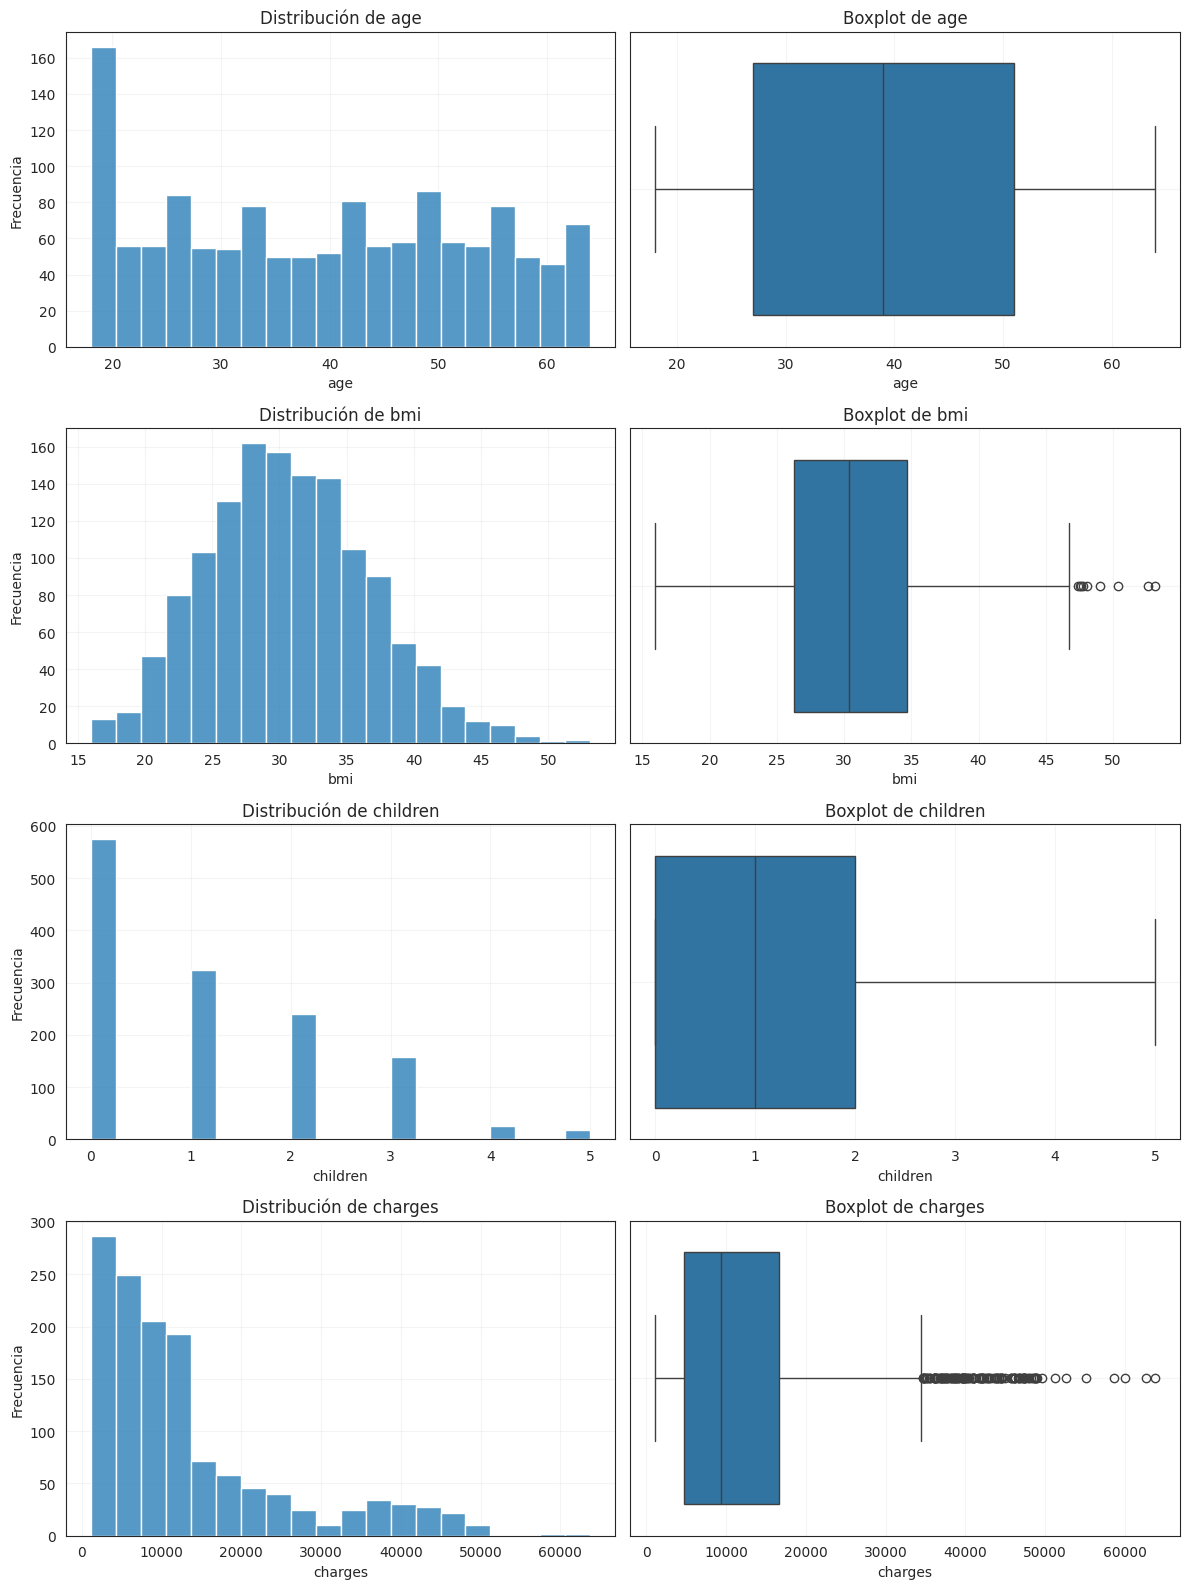

In [7]:
# Se seleccionan automáticamente las variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Histogramas y boxplot de las variables numéricas
sns.set_style("white")

fig, axes = plt.subplots(len(num_vars), 2, figsize=(12,16))

for i, col in enumerate(num_vars):

    # Histograma
    sns.histplot(df[col], bins=20, ax=axes[i,0])
    axes[i,0].set_title(f"Distribución de {col}")
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel("Frecuencia")
    axes[i,0].grid(True, alpha=0.2)   # grid suave

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {col}")
    axes[i,1].set_xlabel(col)
    axes[i,1].grid(True, alpha=0.2)   # grid suave

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observaciones de los graficos

A partir de los histogramas y boxplots se pueden observar lo siguiente:

- **age**: las edades presentan una distribución bastante uniforme entre los 18 y los 64 años. No se observan valores extremos en esta variable, solo una mayor frecuencia de personas menores a 20 años.

- **bmi**: a mayoría de los valores se concentran alrededor de 30, por lo que la distribución presenta una forma similar a una campana, aproximadamente normal. Se observan algunos valores elevados por encima de 45 que podrían considerarse outliers.

- **children**: la mayoría de las personas no tienen hijos o tienen pocos. El valor más frecuente es 0, y a medida que aumenta el número de hijos hay menos observaciones.

- **charges**: la mayor parte de los costes del seguro se concentran en valores relativamente bajos, aunque existen algunos casos con costes mucho más altos que aparecen como outliers en el boxplot.

En general, los valores del dataset tienen sentido y no se observan datos incoherentes.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### Paso 2.4: Análisis univariable de variables categóricas

</div>

In [8]:
# Se seleccionan las posibles variables categoricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns
cat_vars

Index(['sex', 'smoker', 'region'], dtype='str')

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observacion: 

Las variables que son posiblemente categoricas son: `sex`, `smoker`, `region`

</div>

In [9]:
# Resumen estadístico de variables categóricas

df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observacion: 

En efecto se puede evidenciar que en estas tres variables existe el siguiente numero de valores unicos:
* `sex`: 2
* `smoker`: 2
* `region`: 4


</div>

In [10]:
# Se ve la distribución real de cada variable (no solo el resumen)

for col in cat_vars:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts())


Distribución de sex:
sex
male      676
female    662
Name: count, dtype: int64

Distribución de smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

Distribución de region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 💡 Observación variables categoricas

Los valores unicos para estas variables son:
* `sex`: male y female, con una distribución prácticamente equilibrada entre hombres (676) y mujeres (662).
* `smoker`: no y yes, con una clara distribución que se inclina hacia el no (1064) vs un yes con 274.
* `region`: southeast, southwest, northwest, northeast, con una distribución bastante equilibrada entre los cuatro valores.

Corroboramos estas distribuciones con los graficos de countplot a continuación 

</div>

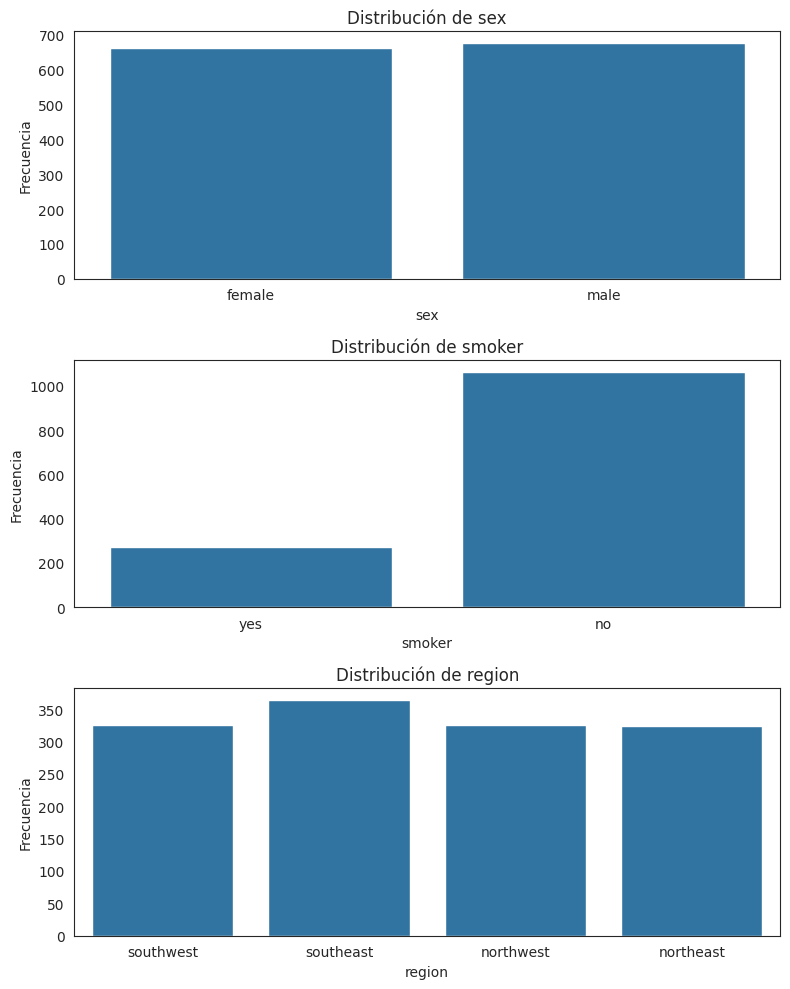

In [11]:
# countplot de las posibles variables categoricas 

fig, axes = plt.subplots(len(cat_vars), 1, figsize=(8, 10))

for i, col in enumerate(cat_vars):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### 🔎 Conclusion variables categoricas

- **sex**: distribución equilibrada entre hombres y mujeres.

- **smoker**: clara mayoría de no fumadores frente a fumadores.

- **region**: distribución bastante uniforme entre las distintas regiones.

Finalmente:

Las variables `sex`, `smoker` y `region` **se consideran categóricas**, ya que representan etiquetas o grupos y no cantidades numéricas sobre las que tenga sentido realizar operaciones matemáticas.

Aunque algunas variables numéricas, como `children`, podrían tratarse como categóricas en ciertos contextos, en este análisis se mantiene como variable numérica al representar una 
cantidad discreta.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### Paso 2.5: variables vs charges

Objetivo: Entender qué variables afectan al coste del seguro (charges)
* ¿cómo cambian los charges según variables numéricas?
* ¿hay diferencias de charges entre grupos?

#### Paso 2.5.1 Variables numéricas vs charges

Se comienza graficando (scatterplot): Se usa este grafico porque es el estándar para analizar la relación entre dos variables numéricas.

</div>

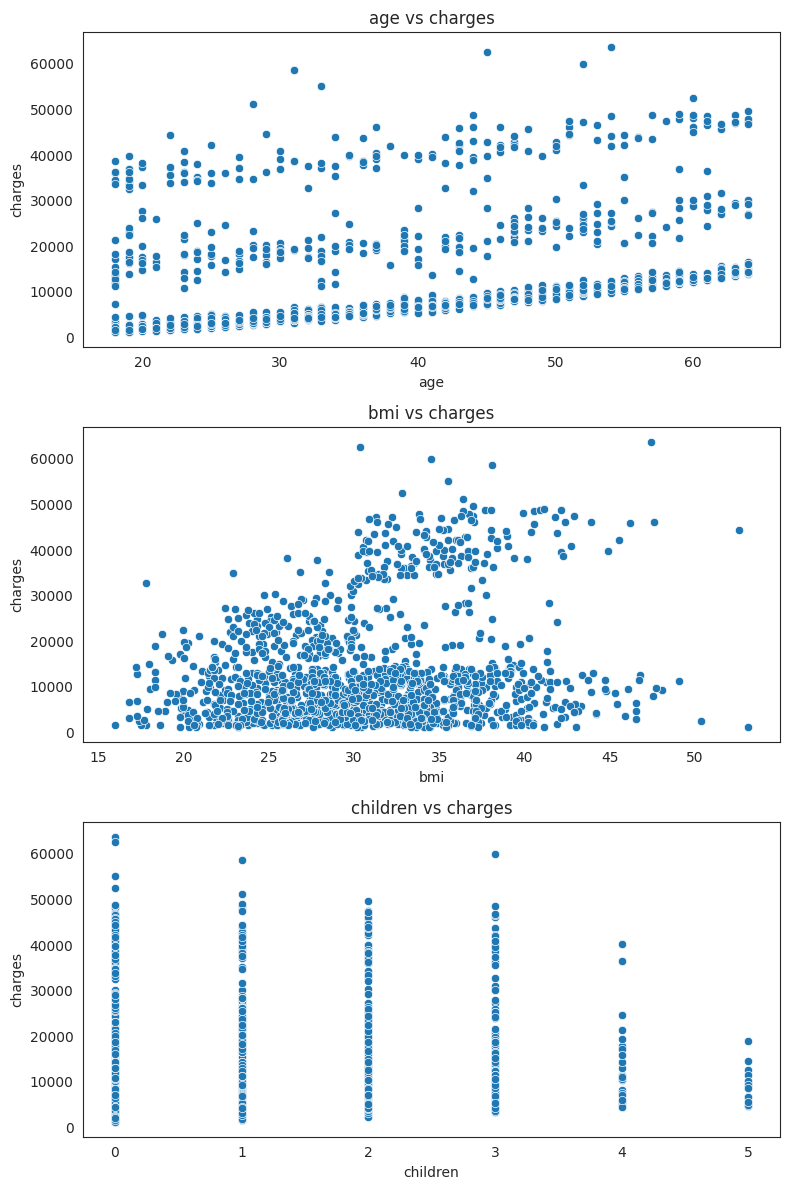

In [12]:
num_vars_sincharges = df.select_dtypes(include=['int64', 'float64']).columns.drop('charges')

fig, axes = plt.subplots(len(num_vars_sincharges), 1, figsize=(8, 12))

for i, col in enumerate(num_vars_sincharges):
    sns.scatterplot(x=col, y='charges', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs charges")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("charges")

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### Observación variables numéricas vs charges

- **age**: se observa una relación positiva moderada entre la edad y los costes del seguro. A medida que aumenta la edad, las primas tienden a ser más altas. Sin embargo, existe una gran dispersión de valores, y se se ven varias bandas de puntos, lo que sugiere que otra variable también está influyendo.

- **bmi**: no se aprecia una relación lineal clara entre el índice de masa corporal y los costes del seguro. No obstante, se observa que los valores mas altos de prima aparecen cuando el bmi supera aprox 30.

- **children**: no parece existir una relación clara entre el número de hijos y los costes del seguro, ya que para cada número de hijos se observan tanto valores bajos como altos de `charges`.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

#### Paso 2.5.2 Variables categóricas vs charges

Se utilizan **boxplots** para analizar la relación entre variables categóricas y la variable objetivo `charges`.  
Este gráfico permite comparar la **distribución de una variable numérica entre diferentes categorías**, mostrando la mediana, la dispersión y posibles valores extremos.

</div>

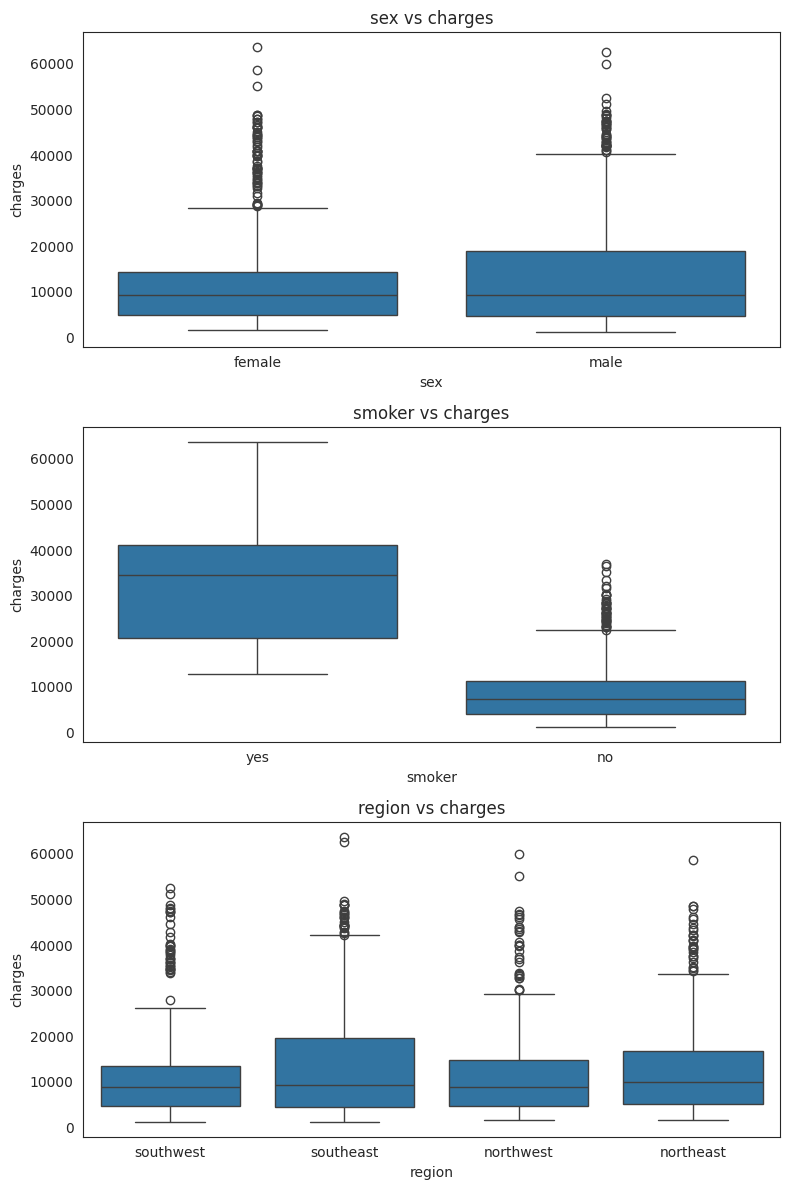

In [13]:
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(8, 12))

for i, col in enumerate(cat_vars):
    sns.boxplot(x=col, y="charges", data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs charges")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("charges")

plt.tight_layout()
plt.show()

<div style="background-color:#fff9e6; border-left:6px solid #f1c40f; padding:15px; border-radius:8px;">

### Observación variables categoricas vs charges

- **sex**: no se observan diferencias significativas en los costes del seguro entre hombres y mujeres. Las distribuciones son muy similares, aunque los hombres presentan ligeramente mayor dispersión y algunos valores más elevados.

- **smoker**: se observa una diferencia muy significativa en los costes del seguro entre fumadores y no fumadores. Los fumadores presentan valores de `charges` considerablemente más altos, tanto en la mediana como en la dispersión, lo que indica que **esta variable tiene una fuerte influencia en el coste del seguro**.

- **region**: no se observa una relación clara entre la región y los costes del seguro. Las distribuciones, medianas y rangos intercuartílicos son similares entre las distintas regiones, lo que sugiere que esta variable no tiene un impacto relevante en el coste.

</div>

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:15px; border-radius:8px;">

## **Conclusiones del EDA**

Tras el análisis exploratorio de los datos, se identificó que:

- La variable **smoker** presenta una fuerte influencia sobre el coste del seguro (`charges`).
- La variable **age** muestra una relación positiva moderada con el coste.
- La variable **bmi** podría tener cierta influencia, aunque no de forma claramente lineal.
- Las variables **sex**, **children** y **region** no muestran una relación significativa con el coste del seguro.

A pesar de ello, **no se eliminarán variables en esta etapa**, ya que:

- El número de variables es reducido y no representa un problema de dimensionalidad.
- Se desea evaluar el impacto de todas las variables en el modelo de regresión.
- Algunas variables que aparentemente tienen baja influencia podrían aportar valor en combinación con otras.

Por tanto, se procederá a incluir todas las variables en la fase de modelado.

</div>

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### 📝 **Paso 3: Construye un modelo de regresión lineal**

No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.

</div>

In [ ]:
# Convertir variables categóricas (texto) en variables numéricas (0 y 1), dado que el modelo de regresión No entiende texto

df_model = pd.get_dummies(df, drop_first=True) # Elimino una de las columnas que se estan generando numericas para evita problemas matemáticos en regresión (multicolinealidad)

df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
# Definición de variables para el modelo de regresión

# X → variables independientes / variables predictoras (features)
# Representan la información de entrada del modelo (edad, bmi, smoker, etc.)

# y → variable dependiente / variable objetivo (target)
# Es la variable que queremos predecir (en este caso, el coste del seguro: charges)

# En términos matemáticos:
# y = f(X) → charges = f(age, bmi, smoker, region, ...)

# Este es un modelo de regresión lineal múltiple, ya que se utilizan múltiples variables independientes

X = df_model.drop("charges", axis=1)
y = df_model["charges"]

# Nota:
# Aunque algunas variables no mostraron fuerte relación en el EDA,
# se mantienen para evaluar su impacto dentro del modelo.

In [ ]:
# Creamos los 4 dataset de entrenamiento y test 


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Entrenamos modelo de regresion 

model = LinearRegression()
model.fit(X_train, y_train)

<div style="background-color:#eef5ff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px;">

### 📝 **Paso 4: Optimiza el modelo anterior**

Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo si fuera posible.

</div>